# ISO 20414:2020 — Test 2: Walking speed in a corridor

Single agent walks a 40 m corridor at 1.0 m/s and should cover it in 40 s (ISO 20414:2020 Table 3). The corridor is extended to 60 m with 10 m acceleration and 10 m isolation buffers; the 40 m measurement segment is unchanged.

In [1]:
from datetime import datetime
print(f"Executed on {datetime.now().astimezone().strftime('%d %B %Y, %H:%M %Z')}")

Executed on 08 July 2026, 10:06 CEST


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from jupedsim_scenarios import load_scenario, run_scenario

In [3]:
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f7f7f5",
    "axes.edgecolor": "#3a3a3a",
    "axes.labelcolor": "#1d1d1d",
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
    "figure.figsize": (8, 5),
})

## Load and run the scenario

In [4]:
SCENARIO_ZIP = Path("scenario_files") / "Iso-02-corridor.zip"
scenario = load_scenario(str(SCENARIO_ZIP))
print(scenario.summary())
result = run_scenario(scenario, seed=42)

Scenario: /Users/chraibi/workspace/PedestrianDynamics/jupedsim-web-community/standards/iso/scenario_files/Iso-02-corridor.zip
  Model:         CollisionFreeSpeedModel
  Seed:          42
  Max time:      100s
  Exits:         1
  Distributions: 1
  Stages:        0
  Zones:         0
  Journeys:      1
  Agents:        ~1
  Journey elems: 2
  Route:         1 distribution, 0 checkpoint, 1 exit
  Sequence:      jps-distributions_0 -> jps-exits_0
    jps-distributions_0: 1 agents


## Measure walking speed across the 40 m segment

Expected transit time at 1 m/s is 40 s.

In [5]:
df = result.trajectory_dataframe().sort_values(['id', 'frame'])
MEAS_START_X = 10.0
MEAS_END_X = 50.0
DIRECTION = 'right'
rows = []
for agent_id, sub in df.groupby('id'):
    if DIRECTION == 'right':
        a = sub[sub.x >= MEAS_START_X]; b = sub[sub.x >= MEAS_END_X]
    else:
        a = sub[sub.x <= MEAS_START_X]; b = sub[sub.x <= MEAS_END_X]
    if a.empty or b.empty:
        continue
    t_in = a.iloc[0].frame / result.frame_rate
    t_out = b.iloc[0].frame / result.frame_rate
    rows.append({'id': int(agent_id), 't_in_s': t_in, 't_out_s': t_out, 'transit_s': t_out - t_in})
transit = pd.DataFrame(rows)
transit['speed_m_s'] = abs(MEAS_END_X - MEAS_START_X) / transit['transit_s']
transit

,id,t_in_s,t_out_s,transit_s,speed_m_s
0,1,8.8,48.8,40.0,1.0


## Plot trajectory x vs t

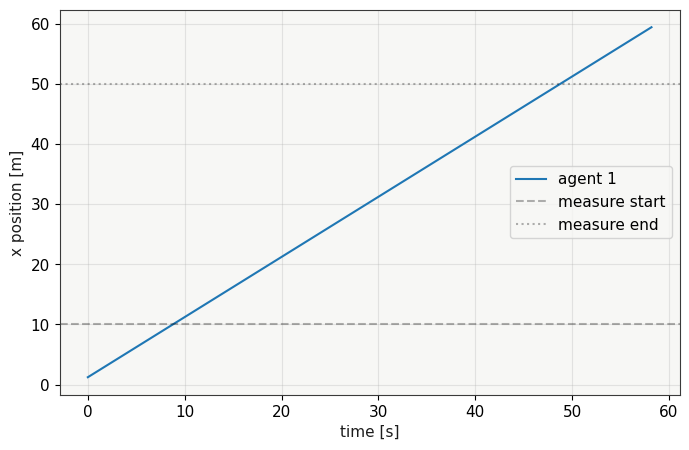

In [6]:
fig, ax = plt.subplots()
for agent_id, sub in df.groupby('id'):
    ax.plot(sub.frame / result.frame_rate, sub.x, label=f'agent {agent_id}')
ax.axhline(MEAS_START_X, color='k', ls='--', alpha=0.3, label='measure start')
ax.axhline(MEAS_END_X, color='k', ls=':', alpha=0.3, label='measure end')
ax.set_xlabel('time [s]'); ax.set_ylabel('x position [m]'); ax.legend()
plt.show()

## Scenario check — geometry and trajectory

Confirm the simulated layout: a 60 m corridor (40 m measurement segment plus 10 m run-up and 10 m buffer) with a single occupant walking left to right to the exit.

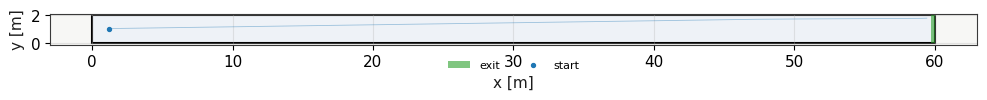

In [7]:
scen = scenario
tdf = df
poly = scen.walkable_polygon
fig, ax = plt.subplots(figsize=(10, 2.2))
gx, gy = poly.exterior.xy
ax.fill(gx, gy, facecolor='#eef2f7', edgecolor='k', lw=1.5, zorder=0)
for interior in poly.interiors:
    ix, iy = interior.xy
    ax.fill(ix, iy, facecolor='white', edgecolor='k', lw=1.0, zorder=1)
for z in scen.zones.values():
    zx = [c[0] for c in z['coordinates']]
    zy = [c[1] for c in z['coordinates']]
    ax.fill(zx, zy, facecolor='tab:orange', alpha=0.18, edgecolor='tab:orange',
            zorder=1, label=f"speed-factor {z.get('speed_factor')} zone")
for e in scen.exits.values():
    ex = [c[0] for c in e['coordinates']]
    ey = [c[1] for c in e['coordinates']]
    ax.fill(ex, ey, facecolor='tab:green', alpha=0.6, zorder=2, label='exit')
for _, sub in tdf.sort_values(['id', 'frame']).groupby('id'):
    ax.plot(sub.x, sub.y, color='tab:blue', lw=0.6, alpha=0.4, zorder=3)
starts = tdf.sort_values(['id', 'frame']).groupby('id').first()
ax.scatter(starts.x, starts.y, s=8, color='tab:blue', zorder=4, label='start')
handles, labels = ax.get_legend_handles_labels()
uniq = dict(zip(labels, handles))
ax.legend(uniq.values(), uniq.keys(), fontsize=8, loc='upper center',
          bbox_to_anchor=(0.5, -0.18), ncol=3, frameon=False)
ax.set_aspect('equal'); ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')
plt.tight_layout(); plt.show()


## Acceptance

In [8]:
TARGET = 1.0
TOL = 0.05
observed = transit['speed_m_s'].mean()
print(f'observed mean speed = {observed:.3f} m/s; target = {TARGET} m/s; '
      f'transit = {transit["transit_s"].mean():.2f} s; expected = 40 s')
assert abs(observed - TARGET) <= TOL, (observed, TARGET)
result.cleanup()

observed mean speed = 1.000 m/s; target = 1.0 m/s; transit = 40.00 s; expected = 40 s


1